# Old City District — Land-Value Assessment Reapportionment

**Purpose:** Old City District (OCD) is a Philadelphia business improvement district that funds
itself with an annual assessment on "taxable commercial properties," apportioned by each property's
share of total OPA-certified assessed value. This notebook models what OCD's *same total budget*
would look like reapportioned by **land value alone**.

**Revenue neutral by construction:** every scenario divides the same Billing Amount across the same
assessable pool. This is a reapportionment of a budget-capped assessment, not a new levy and not a
millage solve like the citywide LVTShift property-tax models.

**Statutory context.** 53 Pa.C.S. Sec. 5607(d)(27)(i) gives BID authorities two apportionment
methods: **(A)** ratio of assessed value to total district assessed value (what OCD uses today), and
**(B)** "in proportion to benefits as ascertained by viewers appointed in accordance with municipal
law" — which is untethered from OPA assessed values and is the statutory hook that could authorize
a land-value basis. This notebook uses OPA land values as an illustrative stand-in for a
viewers-style land valuation; it does not simulate the viewers process itself.

> **Headline caveat, read before using any number here:** the assessable-property rule as written in
> OCD's Plan does **not** reproduce OCD's own published total assessed valuation (it overshoots by
> ~43%). The most likely explanation is condominium treatment — 73% of parcels in the district are
> individual condo units, which the statute says "may not be assessed" individually. We carry three
> readings of the pool as scenarios. Directional conclusions for vacant land, parking, commercial,
> apartments and multi-family are robust across all three; hotels, offices, industrial and mixed-use
> land near zero and are best read as "roughly unchanged." See Sections 5 and 9.


In [1]:
import sys
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')
REPO_ROOT = Path('../..').resolve()

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
BOUNDARY_CACHE = DATA_DIR / 'ocd_boundary.parquet'
HOMESTEAD_CACHE = DATA_DIR / 'ocd_homestead.csv'
PARCELS_CACHE = DATA_DIR / 'parcels.gpq'

# Figures from the current Plan: "2024-2028 Plan and Budget for the Old City District",
# Exhibit A to Philadelphia Bill No. 230628 (enacted 2023-11-13).
OCD_BILLING_AMOUNT_2024 = 1_197_369
OCD_PLAN_TOTAL_ASSESSED_2024 = 1_496_711_735

BID_FEATURESERVER = (
    'https://services.arcgis.com/fLeGjb7u4uXqeF9q/arcgis/rest/services/'
    'business_improvement_districts/FeatureServer/0/query'
)

C:\Users\druss\miniconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. OCD boundary

From OpenDataPhilly's Business Improvement Districts layer (`organization = 'OLD CITY DISTRICT'`).
The Plan describes the service area as "bounded by Florist Street to the north, Walnut/Dock Streets
to the south (including both sides of Walnut St.), 6th Street to the west and Front Street to the
east." The published polygon is treated as authoritative here.

In [2]:
if BOUNDARY_CACHE.exists():
    ocd_boundary = gpd.read_parquet(BOUNDARY_CACHE)
else:
    params = {'outFields': '*', 'where': "organization='OLD CITY DISTRICT'", 'f': 'geojson'}
    resp = requests.get(BID_FEATURESERVER, params=params, timeout=60)
    resp.raise_for_status()
    ocd_boundary = gpd.GeoDataFrame.from_features(resp.json()['features'], crs='EPSG:4326')
    ocd_boundary.to_parquet(BOUNDARY_CACHE)

print(ocd_boundary[['organization', 'bill_number']].to_string(index=False))

     organization  bill_number
OLD CITY DISTRICT       230628


## 2. OPA data: homestead flag + category

The shared Philadelphia parcel cache doesn't carry `homestead_exemption`, so we pull it (plus OPA's
category description) straight from the Carto SQL API, filtered to the OCD polygon.

In [3]:
if HOMESTEAD_CACHE.exists():
    homestead_df = pd.read_csv(HOMESTEAD_CACHE)
else:
    wkt = ocd_boundary.geometry.iloc[0].wkt
    sql = (
        "SELECT parcel_number, homestead_exemption, category_code_description, zoning, market_value "
        "FROM opa_properties_public "
        f"WHERE ST_Within(the_geom, ST_SetSRID(ST_GeomFromText('{wkt}'), 4326))"
    )
    resp = requests.get('https://phl.carto.com/api/v2/sql',
                        params={'q': sql, 'format': 'csv'}, timeout=120)
    resp.raise_for_status()
    HOMESTEAD_CACHE.write_bytes(resp.content)
    homestead_df = pd.read_csv(HOMESTEAD_CACHE)

homestead_df['parcel_number'] = homestead_df['parcel_number'].astype(str)
print(f"{len(homestead_df)} OPA parcels within the OCD boundary")

2382 OPA parcels within the OCD boundary


## 3. Clip the shared Philadelphia parcel cache to OCD

Reuses `cities/philadelphia/data/parcels.gpq` (built by `model.ipynb`) rather than re-scraping.
Join on `parcel_number` with leading zeros stripped — note the cache's row order does *not* match
other Philadelphia exports, so never join these by index.

In [4]:
parcels = gpd.read_parquet(PARCELS_CACHE)
clipped = (gpd.sjoin(parcels, ocd_boundary[['geometry']], predicate='within', how='inner')
             .drop(columns='index_right'))
clipped['parcel_number'] = clipped['parcel_number'].astype(str).str.lstrip('0')

ocd = clipped.merge(homestead_df, on='parcel_number', how='left', suffixes=('', '_carto'))
print(f"{len(ocd)} parcels in OCD; {ocd['homestead_exemption'].isna().sum()} unmatched to OPA")

# OPA identity check: market_value should equal taxable + exempt components.
ocd['taxable_total'] = ocd['taxable_land'].clip(lower=0) + ocd['taxable_building'].clip(lower=0)
ocd['exempt_total'] = ocd['exempt_land'].fillna(0) + ocd['exempt_building'].fillna(0)
mismatch = ((ocd['market_value'] - (ocd['taxable_total'] + ocd['exempt_total'])).abs() > 1).sum()
print(f"parcels where market_value != taxable + exempt: {mismatch}")

2356 parcels in OCD; 6 unmatched to OPA
parcels where market_value != taxable + exempt: 0


## 4. The assessable-property rule

Verbatim from the 2024–2028 Plan (Exhibit A to Bill 230628):

> "OCD funds its operations primarily through assessments on **taxable** commercial properties
> within the district."

> "For purposes of this formula, 'commercial properties' are defined as properties used for any
> activity involving trade or commerce in general, including properties designated for office,
> retail, industrial, wholesale, or other commercial service use, and including income-producing
> residential units that are rented to tenants. Single-family owner-occupied residential properties,
> including single-family owner-occupied residential condominiums, shall be exempt from the OCD
> assessment. Other properties designated for residential use (including single-family homes,
> condominiums, and cooperative units) may also be considered commercial properties if they are not
> used by the Record Owner (as identified on the deed) exclusively as his or her legal residence or
> domicile."

> "District assessments will be calculated annually using the property values certified by the
> Office of Property Assessment for the tax year for which the assessment is imposed, **without any
> reduction for any tax abatements, homestead exclusions, or similar reductions to assessed value**."

So the rule has three moving parts:

1. **Taxable test.** Wholly tax-exempt real estate (institutional, religious, government) is *not*
   "taxable commercial property" and is excluded entirely. Implemented as `taxable_total > 0`.
   Note this is distinct from part 3: an abated or homestead-reduced parcel is still taxable.
2. **Owner-occupancy exemption.** Single-family owner-occupied (including condos) is exempt.
   Everything else — including *non*-owner-occupied single-family and condos, rentals, and vacant
   land under the catch-all — is assessable. We proxy owner-occupancy with OPA's
   `homestead_exemption > 0`, restricted to single-family categories (a homestead flag on a
   mixed-use or multi-family parcel does not make it "single-family owner-occupied").
3. **No reduction for abatements/homestead.** The value base is the *full* certified assessed value
   (`market_value`), not the post-exemption `taxable_total`. This matches
   Sec. 5607(d)(27)(viii), which requires assessed value "without reduction for any value
   attributable to improvements for which an exemption or abatement has been granted under law."

   The Plan's page-7 footnote ("assessed value for **taxable real estate**") could be misread as
   instructing us to use the post-exemption taxable amount. Peer practice settles this: Center City
   District, operating under the same statute, states it is required "to use a property's assessed
   value for taxable purposes, as determined by OPA" and that it "does not recognize abatements
   granted by the City of Philadelphia, nor any additional reductions to value such as the Homestead
   Exemption available to residential owner occupants." So "taxable" describes the *kind* of value
   (assessed for tax purposes), not an instruction to net out exemptions. A post-exemption base is
   therefore **ruled out**, even though it happens to fit OCD's published total well (see Section 5).

**Condominiums — a structural issue.** Sec. 5607(d)(27)(i)(C)(II) provides that for a condominium,
"the unit owners' association ... shall be assessed. **Individual units may not be assessed.**"
Center City District confirms this in practice: "Charges to condominiums within the CCD are payable
to the Condominium Association." Old City is overwhelmingly condo — see below — so OCD's real
billing unit is likely the association, not the individual unit, and any per-parcel model of this
district is structurally approximate.

The land-side base is built symmetrically: full land value = `taxable_land + exempt_land`.

In [5]:
SFH_CATEGORIES = {'SINGLE FAMILY', 'VACANT LAND - RESIDENTIAL'}

ocd['is_taxable'] = ocd['taxable_total'] > 0
ocd['has_homestead'] = ocd['homestead_exemption'].fillna(0) > 0
ocd['owner_occ_sfh'] = ocd['has_homestead'] & ocd['category_code_description'].isin(SFH_CATEGORIES)

ocd['full_land'] = ocd['taxable_land'].clip(lower=0) + ocd['exempt_land'].fillna(0)
ocd['full_value'] = ocd['market_value'].clip(lower=0)

assessable = ocd['is_taxable'] & ~ocd['owner_occ_sfh']

print(f"{len(ocd):>5} parcels in district")
print(f"{(~ocd['is_taxable']).sum():>5} excluded: wholly tax-exempt (not 'taxable real estate')")
print(f"{ocd['owner_occ_sfh'].sum():>5} excluded: single-family owner-occupied (homestead proxy)")
print(f"{assessable.sum():>5} assessable pool")
print()
excluded_exempt = ocd.loc[~ocd['is_taxable']]
print(f"Value removed by the taxable test: ${excluded_exempt['market_value'].sum():,.0f}")
print(excluded_exempt.groupby('category_code_description')['market_value']
      .agg(['count', 'sum']).sort_values('sum', ascending=False).to_string())

# Individual condo units: OPA gives these a '888' parcel-number prefix.
ocd['is_condo_unit'] = ocd['parcel_number'].str.startswith('888')
print(f"\nIndividual condo units (OPA '888' prefix): {ocd['is_condo_unit'].sum()} "
      f"({ocd['is_condo_unit'].mean():.0%} of parcels), "
      f"${ocd.loc[ocd['is_condo_unit'], 'market_value'].sum():,.0f} assessed value")

 2356 parcels in district
   61 excluded: wholly tax-exempt (not 'taxable real estate')
  519 excluded: single-family owner-occupied (homestead proxy)
 1776 assessable pool

Value removed by the taxable test: $640,235,200
                           count          sum
category_code_description                    
COMMERCIAL                    38  561689100.0
INDUSTRIAL                     1   48166700.0
VACANT LAND                   16   15596600.0
MULTI FAMILY                   1    9031000.0
OFFICES                        2    4356800.0
HOTEL                          1    1031000.0
SINGLE FAMILY                  2     364000.0

Individual condo units (OPA '888' prefix): 1709 (73% of parcels), $777,273,800 assessed value


## 5. Validation against OCD's published total — *this does not reconcile*

The Plan states a 2024 total assessed valuation of all commercial properties in the district of
**$1,496,711,735**. Applying the rule as written above gives a substantially larger number. Below we
test several readings of the rule against OCD's published figure.

Assessment vintage is *not* the explanation: a direct Carto pull of TY2024 assessments for parcels
in this boundary totals ~$3.02B across all parcels, matching this cache, so the cache is the right
vintage.

In [6]:
TARGET = OCD_PLAN_TOTAL_ASSESSED_2024
taxable = ocd['is_taxable']
all_sfh = ocd['category_code_description'].isin(SFH_CATEGORIES)

candidates = {
    'A. all parcels, full assessed value': (ocd['parcel_number'].notna(), 'full_value'),
    'B. taxable only, full assessed value': (taxable, 'full_value'),
    'C. taxable & exempt owner-occ SFH, full value  [plan text]': (taxable & ~ocd['owner_occ_sfh'], 'full_value'),
    'D. taxable & exempt ANY homestead, full value': (taxable & ~ocd['has_homestead'], 'full_value'),
    'E. taxable & exclude ALL single-family, full value': (taxable & ~all_sfh, 'full_value'),
    'G. taxable & exempt owner-occ SFH & condo units billed to assoc.':
        (taxable & ~ocd['owner_occ_sfh'] & ~ocd['is_condo_unit'], 'full_value'),
    'X. [RULED OUT] post-exemption TAXABLE value base': (taxable & ~ocd['owner_occ_sfh'], 'taxable_total'),
}

rows = []
for name, (mask, col) in candidates.items():
    v = ocd.loc[mask, col].sum()
    rows.append({'rule': name, 'parcels': int(mask.sum()), 'assessed_value': v,
                 'vs_plan_pct': v / TARGET * 100 - 100})
validation = pd.DataFrame(rows)
print(f"OCD published 2024 total: ${TARGET:,.0f}\n")
print(validation.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))

OCD published 2024 total: $1,496,711,735

                                                            rule  parcels  assessed_value  vs_plan_pct
                             A. all parcels, full assessed value     2356 3,022,357,700.0        101.9
                            B. taxable only, full assessed value     2295 2,382,122,500.0         59.2
      C. taxable & exempt owner-occ SFH, full value  [plan text]     1776 2,137,582,200.0         42.8
                   D. taxable & exempt ANY homestead, full value     1770 2,132,843,700.0         42.5
              E. taxable & exclude ALL single-family, full value      504 1,436,029,200.0         -4.1
G. taxable & exempt owner-occ SFH & condo units billed to assoc.      536 1,565,864,000.0          4.6
                X. [RULED OUT] post-exemption TAXABLE value base     1776 1,469,446,684.3         -1.8


**Reading the table.** The rule as literally written (**C**) overshoots OCD's published total by
roughly 43%. Three readings land close:

- **G** (individual condo units billed to their unit owners' association rather than assessed
  separately) — the most statutorily grounded explanation, since Sec. 5607(d)(27)(i)(C)(II) says
  individual units "may not be assessed," and CCD confirms the practice. Old City is ~73% condo
  units by parcel count, so this is a large structural effect, not a rounding detail.
- **E** (exclude *all* single-family regardless of owner-occupancy) — also close. Would imply the
  homestead flag under-detects owner-occupancy, or that OCD exempts residential more broadly in
  practice than the Plan text describes. E and G overlap heavily, since most Old City single-family
  parcels *are* condo units.
- **X** (post-exemption *taxable* value base) — fits well numerically but is **ruled out** on the
  evidence in Section 4: it contradicts the Plan text, Sec. 5607(d)(27)(viii), and CCD's explicit
  statement that abatements and the Homestead Exemption are disregarded. Shown only to document why
  a close numerical fit was rejected. Good fit alone is not evidence when the mechanism is wrong.

The residual uncertainty is entirely about **which residential parcels are in the pool**, not about
the value base. We cannot fully resolve it from public data — it would take OCD's assessment roll —
so we carry **C, E and G** forward as scenarios.

## 6. Scenario definitions

In [7]:
SCENARIOS = {
    'C: plan text (exempt owner-occ SFH)':
        (taxable & ~ocd['owner_occ_sfh'], 'full_value', 'full_land'),
    'E: exclude all single-family':
        (taxable & ~all_sfh, 'full_value', 'full_land'),
    'G: condo units billed to association':
        (taxable & ~ocd['owner_occ_sfh'] & ~ocd['is_condo_unit'], 'full_value', 'full_land'),
}

def run_scenario(mask, value_col, land_col, budget=OCD_BILLING_AMOUNT_2024):
    """Reapportion a fixed budget from a value base onto a land base, revenue-neutral."""
    p = ocd.loc[mask].copy()
    p['assess_base'] = p[value_col].clip(lower=0)
    p['land_base'] = p[land_col].clip(lower=0)
    p['current_assessment'] = p['assess_base'] / p['assess_base'].sum() * budget
    p['land_assessment'] = p['land_base'] / p['land_base'].sum() * budget
    p['dollar_change'] = p['land_assessment'] - p['current_assessment']
    p['pct_change'] = np.where(p['current_assessment'] > 0,
                               p['dollar_change'] / p['current_assessment'] * 100, np.nan)
    return p

results = {name: run_scenario(*args) for name, args in SCENARIOS.items()}

for name, p in results.items():
    print(f"{name}")
    print(f"    pool={len(p):>5}  land share of base={p['land_base'].sum()/p['assess_base'].sum():.1%}"
          f"  winners={(p['dollar_change']<0).sum():>5}  losers={(p['dollar_change']>0).sum():>4}")
    assert abs(p['current_assessment'].sum() - p['land_assessment'].sum()) < 1, 'not revenue neutral'

C: plan text (exempt owner-occ SFH)
    pool= 1776  land share of base=18.4%  winners= 1261  losers= 515
E: exclude all single-family
    pool=  504  land share of base=20.4%  winners=  407  losers=  97
G: condo units billed to association
    pool=  536  land share of base=20.6%  winners=  436  losers= 100


## 7. Category impact across all three scenarios

This is the key output. Categories where all three scenarios agree on the sign are robust
conclusions; categories that flip are not.

In [8]:
def category_pct(p):
    g = p.groupby('category_code_description').agg(
        cur=('current_assessment', 'sum'), new=('land_assessment', 'sum'))
    return (g['new'] - g['cur']) / g['cur'] * 100

comparison = pd.DataFrame({name: category_pct(p) for name, p in results.items()})
comparison['n_parcels'] = results['C: plan text (exempt owner-occ SFH)'] \
    .groupby('category_code_description').size()
comparison['robust_sign'] = comparison[list(SCENARIOS)].apply(
    lambda r: 'yes' if (r.dropna() > 0).all() or (r.dropna() < 0).all() else 'FLIPS', axis=1)
comparison = comparison.sort_values(list(SCENARIOS)[0], ascending=False)
comparison.round(1)

,C: plan text (exempt owner-occ SFH),E: exclude all single-family,G: condo units billed to association,n_parcels,robust_sign
category_code_description,,,,,
VACANT LAND,443.8,390.7,385.3,35,yes
GARAGE - COMMERCIAL,95.8,76.7,74.7,6,yes
GARAGE - RESIDENTIAL,67.9,51.5,NaN,19,yes
COMMERCIAL,56.4,41.2,58.3,195,yes
HOTEL,10.1,-0.6,-1.7,9,FLIPS
OFFICES,8.8,-1.9,-2.9,29,FLIPS
INDUSTRIAL,8.8,-1.9,-2.9,11,FLIPS
MIXED USE,8.7,-1.9,-3.0,125,FLIPS
MULTI FAMILY,-14.7,-23.0,-23.9,21,yes


## 8. Chart — sensitivity band by category

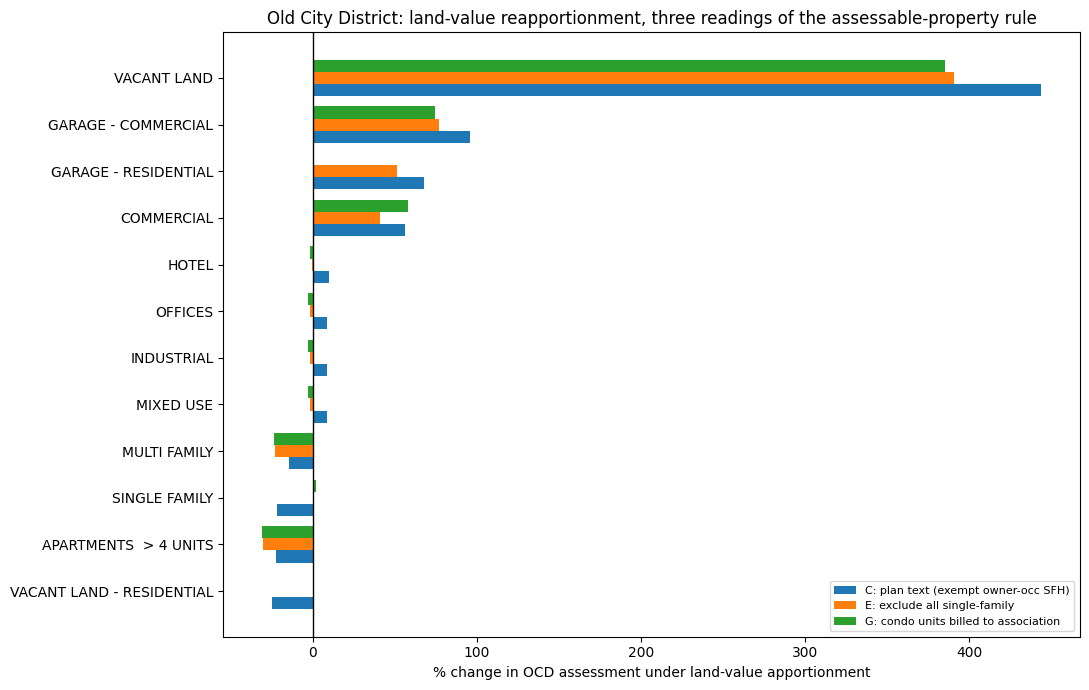

In [9]:
plot_df = comparison.dropna(subset=[list(SCENARIOS)[0]]).sort_values(list(SCENARIOS)[0])
y = np.arange(len(plot_df))
height = 0.26
fig, ax = plt.subplots(figsize=(11, 7))
for i, (name, colour) in enumerate(zip(SCENARIOS, ['#1f77b4', '#ff7f0e', '#2ca02c'])):
    ax.barh(y + (i - 1) * height, plot_df[name], height=height, label=name, color=colour)
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('% change in OCD assessment under land-value apportionment')
ax.set_title('Old City District: land-value reapportionment, three readings of the assessable-property rule')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()

REPORT_DIR = REPO_ROOT / 'analysis' / 'reports' / 'philadelphia_ocd'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(REPORT_DIR / 'category_pct_change.png', dpi=150)
plt.show()

## 9. What is and isn't robust

In [10]:
robust = comparison[comparison['robust_sign'] == 'yes']
flips = comparison[comparison['robust_sign'] == 'FLIPS']
band = comparison[list(SCENARIOS)]

print('ROBUST across all three readings (sign agrees):')
for cat, row in robust.iterrows():
    lo, hi = band.loc[cat].min(), band.loc[cat].max()
    print(f'  {cat:<28} {lo:+7.0f}% to {hi:+7.0f}%   (n={int(row["n_parcels"]) if pd.notna(row["n_parcels"]) else 0})')

print('\nNOT ROBUST (sign flips between readings) — do not cite these directionally:')
for cat, row in flips.iterrows():
    lo, hi = band.loc[cat].min(), band.loc[cat].max()
    print(f'  {cat:<28} {lo:+7.0f}% to {hi:+7.0f}%   (n={int(row["n_parcels"]) if pd.notna(row["n_parcels"]) else 0})')

ROBUST across all three readings (sign agrees):
  VACANT LAND                     +385% to    +444%   (n=35)
  GARAGE - COMMERCIAL              +75% to     +96%   (n=6)
  GARAGE - RESIDENTIAL             +52% to     +68%   (n=19)
  COMMERCIAL                       +41% to     +58%   (n=195)
  MULTI FAMILY                     -24% to     -15%   (n=21)
  APARTMENTS  > 4 UNITS            -31% to     -23%   (n=48)
  VACANT LAND - RESIDENTIAL        -25% to     -25%   (n=1)

NOT ROBUST (sign flips between readings) — do not cite these directionally:
  HOTEL                             -2% to     +10%   (n=9)
  OFFICES                           -3% to      +9%   (n=29)
  INDUSTRIAL                        -3% to      +9%   (n=11)
  MIXED USE                         -3% to      +9%   (n=125)
  SINGLE FAMILY                    -22% to      +2%   (n=1271)


## 10. Largest movers (primary scenario C)

Watch for repeated identical `pct_change` values — those are parcels sitting on OPA's flat 20%
default land ratio rather than a genuine parcel-level land appraisal. See caveats.

In [11]:
primary = results['C: plan text (exempt owner-occ SFH)']
cols = ['parcel_number', 'category_code_description', 'full_value', 'full_land',
        'current_assessment', 'land_assessment', 'dollar_change', 'pct_change']

print('=== Largest increases ===')
print(primary.nlargest(10, 'dollar_change')[cols].to_string(index=False,
      float_format=lambda x: f'{x:,.0f}'))
print('\n=== Largest decreases ===')
print(primary.nsmallest(10, 'dollar_change')[cols].to_string(index=False,
      float_format=lambda x: f'{x:,.0f}'))

land_ratio = (primary['full_land'] / primary['full_value']).round(4)
print(f"\nParcels at OPA's exact 0.20 default land ratio: "
      f"{(land_ratio == 0.20).sum()} of {len(primary)} ({(land_ratio == 0.20).mean():.1%})")

=== Largest increases ===
parcel_number category_code_description  full_value  full_land  current_assessment  land_assessment  dollar_change  pct_change
    885751880                COMMERCIAL   4,776,700  4,776,700               2,676           14,550         11,874         444
    883409600       GARAGE - COMMERCIAL  17,045,000  6,136,200               9,548           18,691          9,143          96
    885867220               VACANT LAND   3,500,000  3,500,000               1,961           10,661          8,700         444
    885720860                COMMERCIAL   2,900,000  2,900,000               1,624            8,833          7,209         444
    885761200                COMMERCIAL   2,789,000  2,789,000               1,562            8,495          6,933         444
    885721300               VACANT LAND   2,338,800  2,338,800               1,310            7,124          5,814         444
    885791760                COMMERCIAL   2,137,500  2,137,500               1,197   

## 11. Export

In [12]:
EXPORT_DIR = REPO_ROOT / 'analysis' / 'data'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_cols = ['parcel_number', 'category_code_description', 'full_value', 'full_land',
               'current_assessment', 'land_assessment', 'dollar_change', 'pct_change']
primary[export_cols].to_csv(EXPORT_DIR / 'philadelphia_ocd_land_assessment.csv', index=False)
comparison.to_csv(EXPORT_DIR / 'philadelphia_ocd_land_assessment_by_category.csv')
validation.to_csv(EXPORT_DIR / 'philadelphia_ocd_rule_validation.csv', index=False)
print('Exported parcel-level, category sensitivity, and rule-validation tables to analysis/data/')

Exported parcel-level, category sensitivity, and rule-validation tables to analysis/data/


## Caveats

1. **The assessable-property rule does not fully reconcile with OCD's published total** (Section 5).
   The Plan text as written overshoots by ~43%. The value base is settled (full assessed value, not
   post-exemption — confirmed by statute, Plan text, and CCD's published methodology). The residual
   uncertainty is *which residential parcels sit in the pool*, most likely driven by condominium
   treatment. Fully resolving it requires OCD's actual assessment roll.

2. **Condominium billing makes any per-parcel model structurally approximate.** 73% of district
   parcels are individual condo units, which Sec. 5607(d)(27)(i)(C)(II) says "may not be assessed"
   individually — the unit owners' association is assessed instead and passes the charge through via
   condo fees. So parcel-level "winners and losers" for condo units describe economic incidence, not
   who actually receives a bill.

3. **Robust vs. not (Section 9).** Vacant land, commercial parking, commercial, apartments and
   multi-family hold their sign across all three scenarios. Hotels, offices, industrial and mixed-use
   land within roughly +/-10% of zero and should be described as "roughly unchanged," not
   directionally.

4. **OPA's land/improvement split is unreliable.** Philadelphia's OPA assigns a flat 20% land ratio
   to a large share of improved parcels (see `philadelphia-data-architecture` memory), which is why
   clusters of parcels show identical percentage changes. This is precisely the reason the legal
   theory favors an *independent* land valuation via the statutory "viewers" method rather than
   reusing OPA's splits — this notebook uses OPA land values only as an illustrative stand-in, not a
   proposal-ready valuation.

5. **Owner-occupancy is proxied by OPA's homestead flag**, which is a different test from OCD's
   deed-based "Record Owner ... exclusively as his or her legal residence" standard, and which
   additionally requires the owner to have filed with the City. Under-filing would misclassify
   owner-occupants as assessable. The gap between scenarios C and E is largely a measure of this
   uncertainty.

6. **Not a legal simulation of Method (B).** This models the economic effect of a land-value
   apportionment. It does not simulate the "viewers ascertaining benefit" proceeding that would
   actually be required to implement Method (B) under Sec. 5607(d)(27)(i)(B), whose Philadelphia
   procedure is itself unconfirmed.

7. **Scope.** Single district, single budget year (2024 Billing Amount), single assessment vintage.
   No behavioral response (redevelopment, appeals) is modeled.
